# Multi-Model Switching with Contact


## Goal
Demonstrate runtime switching between pendulum models (FMU/OpenSim/FEM) during contact and evaluate the resulting trajectory.

## Model Map

![System Graph](figures/graphs/05_multi_model_graph.svg)

## Assumptions and Scope
- Contact modeled as discrete events
- Fixed-step co-simulation

## Prerequisites and Setup

In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection


## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

We refer to the monolithic Modelica simulation as "Modelica" in the following. The simulation results are obtained by running the `RigidContact` example model in *OpenModelica* using the `OMPython` interface. The model can be found in the `demos/ControlledPendulum/src/modelica/ControlledPendulum/Examples/Contact/RigidContact.mo` package.

The `RigidContact` model and the here used co-simulation with multi-model pendulum are only to some extent comparable, as the `RigidContact` model includes a discrete rigid contact, while the multi-model pendulum uses the underlying `FEMPendulum` model with a continuous contact formulation.

However, the `RigidContact` model serves as a useful reference for the overall system behavior during contact and allows us to evaluate the multi-model switching approach in a realistic scenario.

Since the `FEMPendulum` model uses a higly stiff contact formulation, we expect the multi-model switching approach to closely follow the reference trajectory during contact.

In [4]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset':'true'})
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'pid.I_out', 'pendulum.contact')
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Instantiate FMU Components

In [5]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

### Setpoint

In [6]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")
print_parameteres(setpoint)

Parameters of Setpoint:
  - amplitude: 0.3490658503988659 rad
  - frequency: 3.0 Hz
  - offset: 0.0 rad
  - phase: 0.0 rad


### PID Controller

In [7]:
class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")
        self.use_reset = False  # Flag to control whether to apply reset on event
    
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

print_parameteres(pid)

Parameters of PID:
  - Kd: 0.02
  - Ki: 8.0
  - Kp: 12.0
  - uMax: 1.0
  - uMin: -1.0


### Drive

In [8]:
drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")
print_parameteres(drive)

Parameters of Drive:
  - I_max: 10.0 A
  - L_arm: 0.000121 H
  - R_arm: 0.151 Ohm
  - V_rated: 48.0 V
  - V_supply: 16.0 V
  - eta: 0.85
  - gearRatio: 60.0
  - k_t: 0.03 m·N/A
  - n_0: 12916.0 1/min


### Pendulum

In [10]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 0.4
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)
pendulum._allow_mode_switching = True
pendulum.hysteresis.dwell_time = 0.01

def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0.0
    return theta - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)


### Angle Sensor and Decoder

In [11]:
angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")
print_parameteres(angle_sensor)

Parameters of Angle Sensor:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


In [12]:
angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")

print_parameteres(angle_decoder)

Parameters of Angle Decoder:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


## Define Connections

In [13]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]

## Build and Initialize the System

In [14]:
system = System(name="Pendulum System with Master Pendulum")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.add_event_connection(event_connection_1)
system.add_event_connection(event_connection_2)

system.initialize(t0=0.0)

system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

## Visualize the System Graph

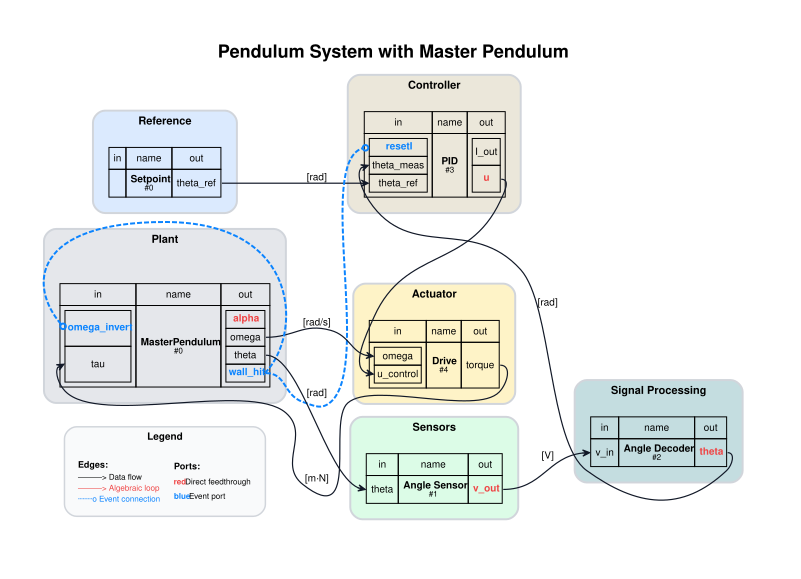

In [15]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Setup Pendulum Monitoring

In [16]:
# pendulum.setup_monitoring()
# pendulum.display_monitoring()

## Run Simulation

In [17]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

system.run(t, t_end, dt)

[FEM_Pendulum] Event 'wall_hit' at t=0.172463s.
[FEM_Pendulum] Event 'wall_hit' at t=0.210994s.
[FEM_Pendulum] Event 'wall_hit' at t=0.249994s.
[FEM_Pendulum] Event 'wall_hit' at t=0.288925s.
[FEM_Pendulum] Event 'wall_hit' at t=0.328338s.


In [32]:
system_res_file = _repo / "demos/ControlledPendulum/artifacts/results/master_pendulum_system.csv"
system_res_file.parent.mkdir(parents=True, exist_ok=True)
system.history.save_csv(filepath=system_res_file)

## Collect Results

In [19]:
history = system.get_history()
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

ref_history = history["Setpoint"]
setpoint_time, data = ref_history
theta_ref = data["theta_ref"]

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

In [20]:
event_history = history['Events']
event_times_dense = event_history[('MasterPendulum', 'wall_hit')]
event_times_float = [dt.t for dt in event_times_dense]
event_indices = np.where(ref_sol_reset['pendulum.contact'] > 0)[0]
event_times_ref_indices = np.where(ref_sol_reset['time'][event_indices] <= t_end)[0]
event_times_ref = ref_sol_reset['time'][event_indices][event_times_ref_indices][::2]

diff_event_times = np.array(event_times_float) - np.array(event_times_ref)

df_events = pd.DataFrame({
    "syssimx (s)": event_times_float,
    "Modelica (s)": event_times_ref,
    "Delta (s)": diff_event_times,
})
df_events.index.name = "Event"
df_events.style.format("{:.6f}")

,syssimx (s),Modelica (s),Delta (s)
Event,,,
0,0.172463,0.172112,0.000350
1,0.210994,0.211092,-0.000098
2,0.249994,0.250071,-0.000077
3,0.288925,0.289050,-0.000125
4,0.328338,0.328029,0.000308


In [21]:
marker_size = 3
palette = {
    "fem": "#1f77b4",
    "opensim": "#ff7f0e",
    "fmu": "#2ca02c",
    "setpoint": "#d62728",
}

fem_style = {
    "color": palette["fem"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
opensim_style = {
    "color": palette["opensim"],
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 2.5,
}
fmu_style = {
    "color": palette["fmu"],
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 2.5,
}

## Plot: Multi-Model Switching
This plot overlays all three sub-models and the setpoint.

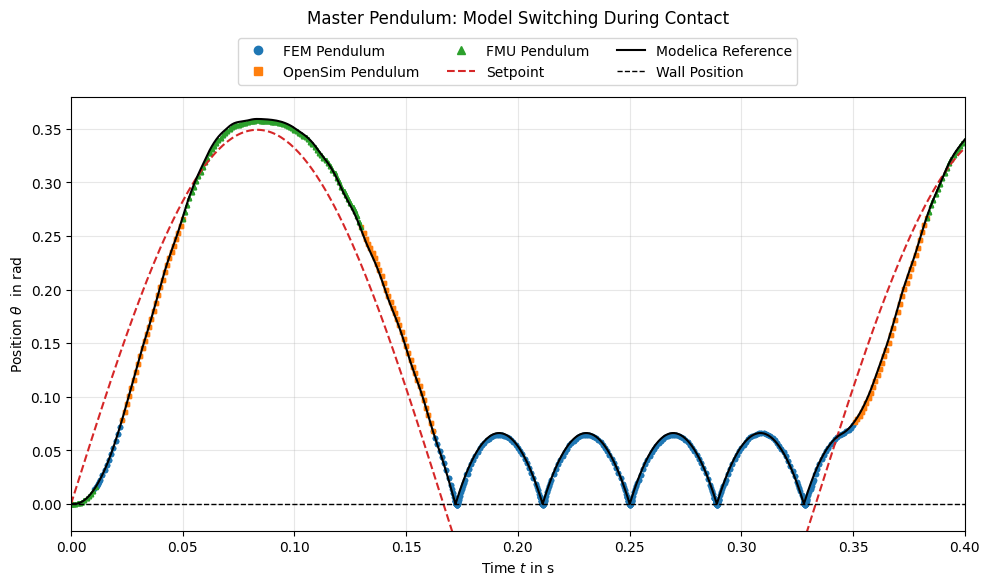

In [22]:
plt.figure(figsize=(10, 6))
plt.title("Master Pendulum: Model Switching During Contact", y=1.15)
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **fem_style)
plt.plot(t_opensim, theta_opensim, label="OpenSim Pendulum", **opensim_style)
plt.plot(t_fmu, theta_fmu, label="FMU Pendulum", **fmu_style)
plt.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5)
plt.plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'k-', label="Modelica Reference", markersize=1)
plt.ylim(-0.025, 0.38 )
plt.axhline(0, color='black', linestyle='--', linewidth=1, label="Wall Position")
plt.xlim(0, t_end)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $\theta$  in rad")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot: Contact Windows



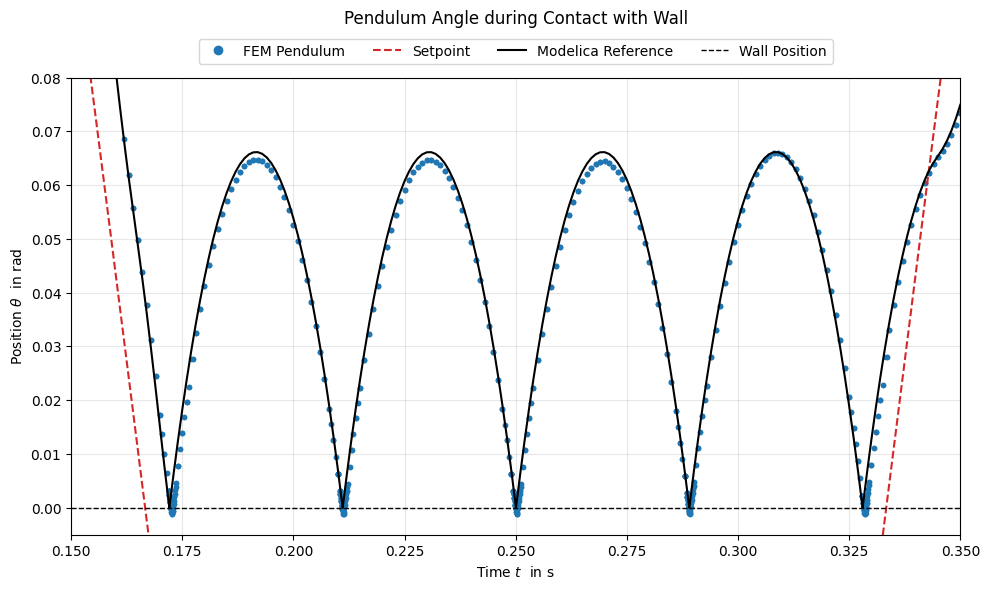

In [23]:
plt.figure(figsize=(10, 6))
plt.title("Pendulum Angle during Contact with Wall", y=1.1 )
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **fem_style)
plt.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5)
plt.plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'k-', label="Modelica Reference", markersize=5)

plt.axhline(0, color='black', linestyle='--', linewidth=1, label="Wall Position")
plt.xlim(0.15, 0.35)
plt.ylim(-0.005, 0.08)
plt.xlabel(r"Time $t$  in s")
plt.ylabel(r"Position $\theta$  in rad")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=4, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot: PID Integrator Output

We can observe that the PID intergartor output follows closely the PID integrator trajectory of the Modelica reference.

When the pendulum hits the wall, both the PID integrator for the Modelica reference and the `syssimx`simulation react to the contact event with the reset of the integrator state. The integrator starts after every contact from zero.

This enables the PID controller to react to the contact event and drive the pendulum back to the setpoint.

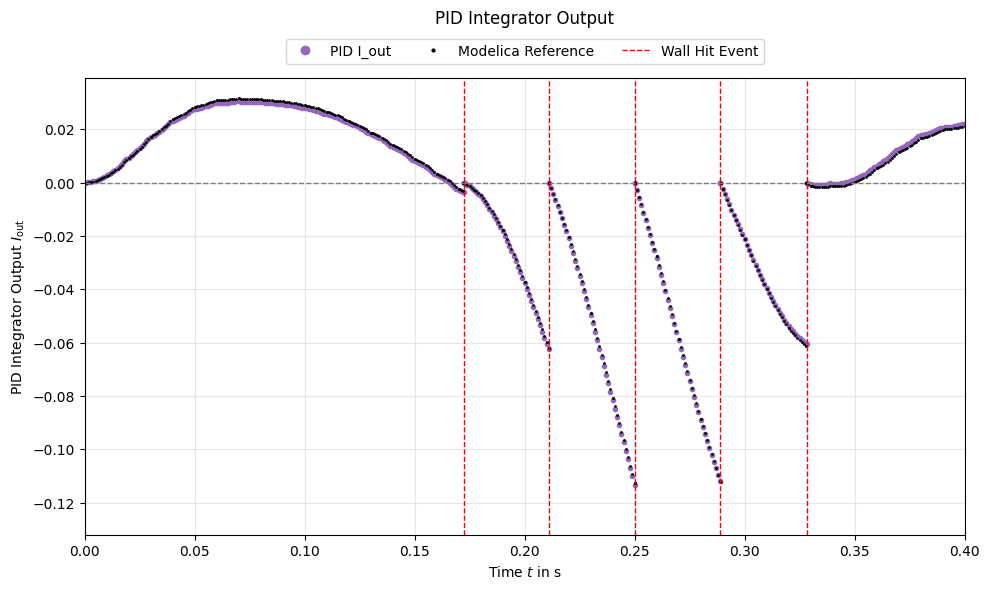

In [31]:
pid_hist = history['PID']
t_pid, data_pid = pid_hist
i_out = data_pid.get('I_out', None)

plt.figure(figsize=(10, 6))
plt.plot(t_pid, i_out, 'o', label="PID I_out", color="#9467bd", markersize=3)
plt.plot(ref_sol_reset['time'], ref_sol_reset['pid.I_out'], 'k.', label="Modelica Reference", markersize=2)
plt.axhline(0.0, color="#7f7f7f", linestyle="--", linewidth=1)

for event_time in event_times_float:
    plt.axvline(event_time, color="red", linestyle="--", linewidth=1, label="Wall Hit Event" if event_time == event_times_float[0] else None)

plt.xlim(0, t_end)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"PID Integrator Output $I_{\text{out}}$")
plt.title("PID Integrator Output", y=1.1)
plt.legend(markerscale=2, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary
- The MasterPendulum switches between FMU, OpenSim, and FEM based on contact events.
- Contact windows show the high-resolution FEM response.
- The highly stiff FEM contact formulation closely follows the Modelica reference during contact.